# Fase 2: pipeline ergonomico inicial

Objetivo de esta libreta:
- dejar fijado el contexto tecnico con el benchmark ya hecho
- reutilizar modulos `.py` en vez de cargar el notebook con logica larga
- ejecutar una primera demo funcional del pipeline ergonomico sobre imagenes reales

Alcance de esta iteracion:
- caso de uso de webcam frontal
- analisis interpretable de tren superior
- primera capa de variables y reglas ergonomicas

Criterio de cierre:
- seleccionar una muestra equilibrada del dataset base
- ejecutar `MediaPipe Pose` sobre esa muestra
- transformar landmarks en variables posturales legibles
- clasificar cada imagen en `adequate`, `improvable`, `risk` o `insufficient_data`





In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 40
pd.options.display.float_format = "{:,.3f}".format

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")





PROJECT_ROOT: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I
SRC_DIR: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/src


In [2]:
from ergonomics import (
    MEDIAPIPE_TASK_MODEL_PATH,
    MediaPipePoseConfig,
    analyze_pose_dataframe,
    choose_reference_models,
    draw_pose_overlay,
    load_benchmark_artifacts,
    plot_dataset_group_distribution,
    plot_dataset_volumes,
    plot_group_comparison,
    plot_metric_by_group,
    plot_model_overview,
    plot_status_by_group,
    plot_status_distribution,
    rank_models,
    run_mediapipe_pose_batch,
    select_balanced_sample,
    summarize_available_datasets,
    summarize_dataset_groups,
)





## 1. Punto de partida del proyecto

Antes de movernos a reglas ergonomicas, conviene dejar documentado el suelo tecnico:
- que datasets tenemos disponibles ya en local
- que benchmark previo tenemos guardado
- cual es el modelo de referencia para esta fase

Esta seccion no reejecuta el benchmark. Solo recupera y resume lo que ya existe para no perder contexto entre iteraciones.





,label,format,is_available,total_images,split_count,group_count,notes
0,Posture Correction v4 folder,folder,True,4666,3,3,Webcam frontal. Es el dataset mas cercano al c...
1,Posture Detection folder,folder,True,1713,3,5,Segundo contraste por carpetas con clases Good...
2,Sitting Posture folder,folder,True,1595,3,7,Version por carpetas con etiquetas de postura ...
3,Sitting Posture 4 keypoint,coco,True,655,3,3,Mayormente lateral. Buen punto de partida para...
4,Desk Posture coco,coco,True,148,3,3,"Dataset pequeno con pose etiquetada, util para..."


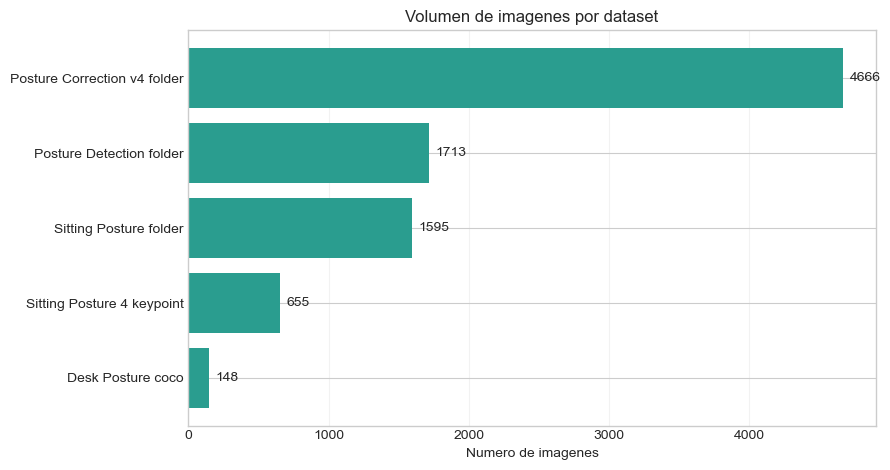

In [3]:
dataset_summary = summarize_available_datasets()
display(
    dataset_summary[
        ["label", "format", "is_available", "total_images", "split_count", "group_count", "notes"]
    ]
)

fig, ax = plot_dataset_volumes(dataset_summary)
plt.show()





,model,backend,phase_fit_score,upper_body_ready_pct,required_keypoint_rate,runtime_ms_median,full_ergonomic_ready_pct
0,mediapipe_pose,mediapipe_tasks,65.196,84.205,62.945,22.524,0.193
1,movenet,tensorflow_cpu,53.727,41.406,53.178,8.541,8.487
2,yolo_pose,torch_cuda:0,32.408,9.194,44.725,9.535,0.000


,primary_model,backup_model,current_scope,rationale
0,mediapipe_pose,movenet,upper_body_frontal_webcam,Se prioriza mediapipe_pose porque lidera la fa...


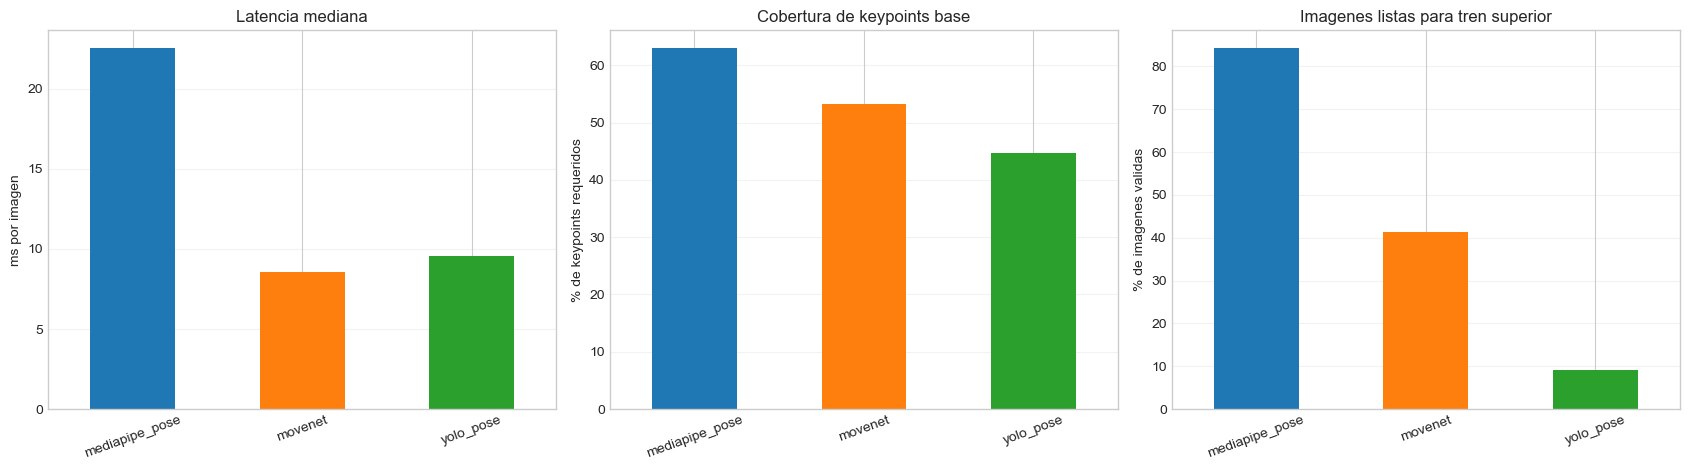

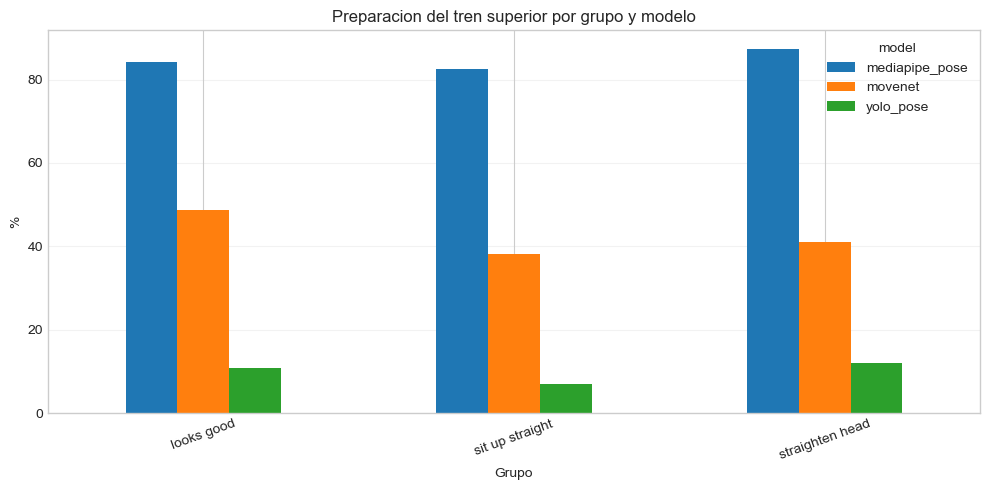

In [4]:
artifacts = load_benchmark_artifacts()
ranked_models = rank_models(artifacts.summary)
decision = choose_reference_models(artifacts.summary)

display(
    ranked_models[
        [
            "model",
            "backend",
            "phase_fit_score",
            "upper_body_ready_pct",
            "required_keypoint_rate",
            "runtime_ms_median",
            "full_ergonomic_ready_pct",
        ]
    ]
)

display(
    pd.DataFrame(
        [
            {
                "primary_model": decision.primary_model,
                "backup_model": decision.backup_model,
                "current_scope": decision.current_scope,
                "rationale": decision.rationale,
            }
        ]
    )
)

fig, axes = plot_model_overview(artifacts.summary)
plt.show()

fig, ax = plot_group_comparison(
    artifacts.group_summary,
    metric="upper_body_ready_pct",
    title="Preparacion del tren superior por grupo y modelo",
)
plt.show()





## 2. Dataset base y muestra de trabajo

En vez de lanzar toda la fase 2 sobre miles de imagenes desde el principio, aqui usamos una muestra pequena y equilibrada.
Esto permite:
- validar rapidamente que el pipeline nuevo funciona
- inspeccionar manualmente casos de ejemplo
- iterar sobre reglas y umbrales sin esperar una ejecucion larga

Si esta demo se comporta bien, el siguiente paso sera escalar la ejecucion a mas imagenes del mismo dataset.





,split,group,image_count
0,train,sit up straight,1663
1,train,looks good,837
2,train,straighten head,809
3,valid,sit up straight,297
4,valid,straighten head,222
5,valid,looks good,163
6,test,sit up straight,386
7,test,straighten head,184
8,test,looks good,105


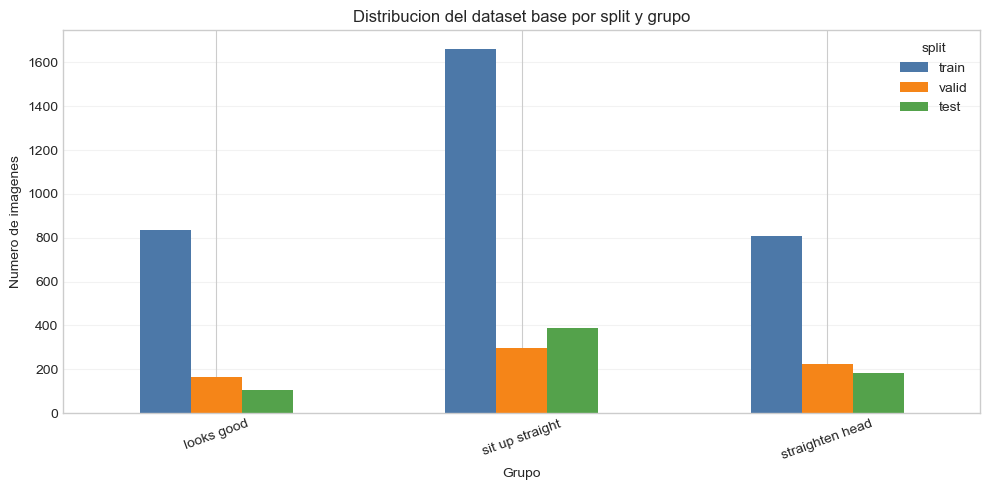

,image_path,group,split
0,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,test
1,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,train
2,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,train
3,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,looks good,valid
4,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,sit up straight,test
5,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,sit up straight,test
6,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,sit up straight,train
7,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,sit up straight,train
8,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,straighten head,test
9,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,straighten head,train



**Configuracion de la demo**

- Dataset base: `posture_correction_v4_folder_v1`
- Muestra por grupo: `4`
- Total de imagenes en la muestra: `12`
- Modelo de landmarks: `mediapipe_pose`
- Asset local de MediaPipe: `/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/models/mediapipe/pose_landmarker_lite.task`


In [5]:
TARGET_DATASET_KEY = "posture_correction_v4_folder_v1"
SAMPLE_PER_GROUP = 4
VISIBILITY_THRESHOLD = 0.35

target_group_summary = summarize_dataset_groups(TARGET_DATASET_KEY)
display(target_group_summary)

fig, ax = plot_dataset_group_distribution(
    target_group_summary,
    title="Distribucion del dataset base por split y grupo",
)
plt.show()

sample_df = select_balanced_sample(
    TARGET_DATASET_KEY,
    per_group=SAMPLE_PER_GROUP,
    splits=("train", "valid", "test"),
    seed=7,
)
display(sample_df)

display(
    Markdown(
        f"""
**Configuracion de la demo**

- Dataset base: `{TARGET_DATASET_KEY}`
- Muestra por grupo: `{SAMPLE_PER_GROUP}`
- Total de imagenes en la muestra: `{len(sample_df)}`
- Modelo de landmarks: `{decision.primary_model}`
- Asset local de MediaPipe: `{MEDIAPIPE_TASK_MODEL_PATH}`
"""
    )
)





## 3. Inferencia de pose sobre la muestra

Aqui ya dejamos el simple contexto y entramos en el siguiente paso real del proyecto.
La idea es:
1. correr `MediaPipe Pose` sobre una muestra pequena del dataset base
2. guardar landmarks normalizados y visibilidades
3. reutilizar esos landmarks como entrada del modulo ergonomico

En esta iteracion no hacemos feedback en tiempo real ni video. Solo validamos el flujo sobre imagen estatica.





In [6]:
pose_config = MediaPipePoseConfig(
    model_path=MEDIAPIPE_TASK_MODEL_PATH,
    min_visibility=VISIBILITY_THRESHOLD,
)
pose_demo_df = run_mediapipe_pose_batch(sample_df, config=pose_config)

display(
    pose_demo_df[
        [
            "image_name",
            "group",
            "split",
            "pose_detected",
            "visible_landmarks_count",
            "pose_landmarks_count",
        ]
    ]
)





I0000 00:00:1776616234.162871   53444 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776616234.582337   53444 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776616236.442024   53444 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776616237.721393   60650 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:17

,image_name,group,split,pose_detected,visible_landmarks_count,pose_landmarks_count
0,extract0981_jpg.rf.1085684f0858b35bdc98b3e73de...,looks good,test,True,5,33
1,extract1565_jpg.rf.8fabc715fae4681d745b97a6db1...,looks good,train,True,6,33
2,mb20116_jpg.rf.901eb927b0978617827e03ced690472...,looks good,train,True,4,33
3,extract0307_jpg.rf.25ba9ee23d8b5a0a00325bd01c5...,looks good,valid,True,4,33
4,extract1049_jpg.rf.7a272f1bce23e4f0b2976d09af6...,sit up straight,test,True,5,33
5,extract1103_jpg.rf.41fdf7fdb19e91439fecb05d6d0...,sit up straight,test,True,4,33
6,extract1683_jpg.rf.0a78a029862a524399d347d5231...,sit up straight,train,True,5,33
7,extract2656_jpg.rf.4ac9aa3508d3e85799e8dfd9b62...,sit up straight,train,True,3,33
8,extract1017_jpg.rf.f377c87b42f7a8e490e29182a01...,straighten head,test,True,4,33
9,extract1451_jpg.rf.63508a85f67903c920de0ae22b1...,straighten head,train,True,6,33


## 4. Variables posturales y reglas iniciales

En esta primera version no intentamos resolver un ROSA completo.
Nos centramos en variables que si tienen sentido con webcam frontal y tren superior:
- inclinacion de hombros
- simetria escapular a partir de la diferencia de altura entre hombros
- desplazamiento lateral de la cabeza respecto al eje de hombros
- inclinacion lateral del cuello
- inclinacion del tronco visible
- angulos de codo izquierdo y derecho

Las reglas son deliberadamente simples e interpretables. Si funcionan y son utiles, luego se refinan.





In [7]:
analysis_df = analyze_pose_dataframe(
    pose_demo_df,
    visibility_threshold=VISIBILITY_THRESHOLD,
)

demo_results_df = pose_demo_df[
    [
        "image_path",
        "visible_landmarks_count",
        "pose_landmarks_count",
        "pose_detected",
    ]
].merge(
    analysis_df,
    on=["image_path", "pose_detected"],
    how="inner",
)

display(
    demo_results_df[
        [
            "image_name",
            "group",
            "overall_status",
            "shoulder_tilt_deg",
            "shoulder_height_diff_ratio",
            "head_lateral_offset_ratio",
            "neck_tilt_deg",
            "trunk_tilt_deg",
            "left_elbow_angle_deg",
            "right_elbow_angle_deg",
            "feedback",
        ]
    ]
)





,image_name,group,overall_status,shoulder_tilt_deg,shoulder_height_diff_ratio,head_lateral_offset_ratio,neck_tilt_deg,trunk_tilt_deg,left_elbow_angle_deg,right_elbow_angle_deg,feedback
0,extract0981_jpg.rf.1085684f0858b35bdc98b3e73de...,looks good,adequate,0.808,0.014,0.053,3.479,None,NaN,NaN,Sin alertas principales en esta primera revision.
1,extract1565_jpg.rf.8fabc715fae4681d745b97a6db1...,looks good,risk,3.750,0.065,0.044,2.753,None,NaN,150.290,Intenta mantener los hombros mas nivelados y r...
2,mb20116_jpg.rf.901eb927b0978617827e03ced690472...,looks good,improvable,2.000,0.035,0.001,0.047,None,NaN,NaN,Intenta mantener los hombros mas nivelados y r...
3,extract0307_jpg.rf.25ba9ee23d8b5a0a00325bd01c5...,looks good,improvable,2.150,0.038,0.010,0.749,None,NaN,NaN,Intenta mantener los hombros mas nivelados y r...
4,extract1049_jpg.rf.7a272f1bce23e4f0b2976d09af6...,sit up straight,risk,7.916,0.138,0.009,0.645,None,NaN,NaN,Intenta mantener los hombros mas nivelados y r...
5,extract1103_jpg.rf.41fdf7fdb19e91439fecb05d6d0...,sit up straight,risk,4.343,0.076,0.033,2.289,None,NaN,NaN,Intenta mantener los hombros mas nivelados y r...
6,extract1683_jpg.rf.0a78a029862a524399d347d5231...,sit up straight,improvable,2.566,0.045,0.024,1.504,None,NaN,NaN,Intenta mantener los hombros mas nivelados y r...
7,extract2656_jpg.rf.4ac9aa3508d3e85799e8dfd9b62...,sit up straight,risk,13.090,0.226,0.253,17.949,None,NaN,NaN,Recoloca la cabeza sobre el eje de los hombros...
8,extract1017_jpg.rf.f377c87b42f7a8e490e29182a01...,straighten head,adequate,0.941,0.016,0.026,1.612,None,NaN,NaN,Sin alertas principales en esta primera revision.
9,extract1451_jpg.rf.63508a85f67903c920de0ae22b1...,straighten head,risk,6.867,0.120,0.015,1.026,None,15.276,NaN,Intenta mantener los hombros mas nivelados y r...


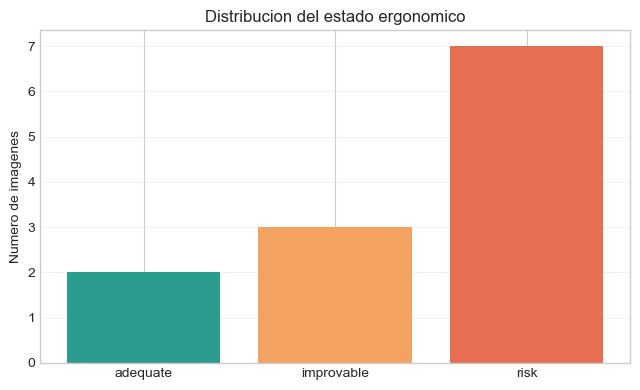

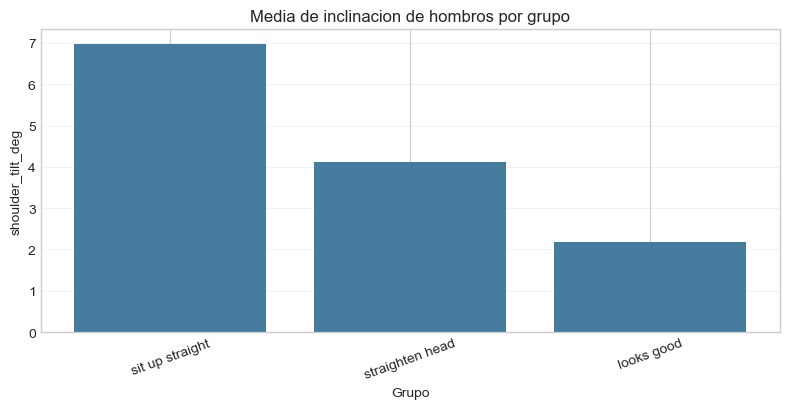

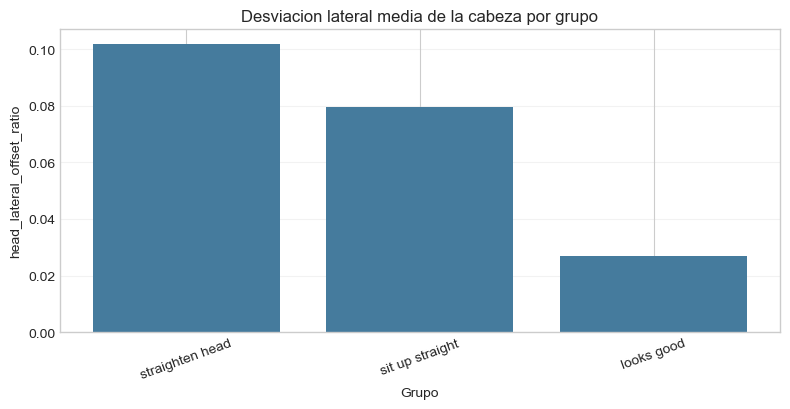

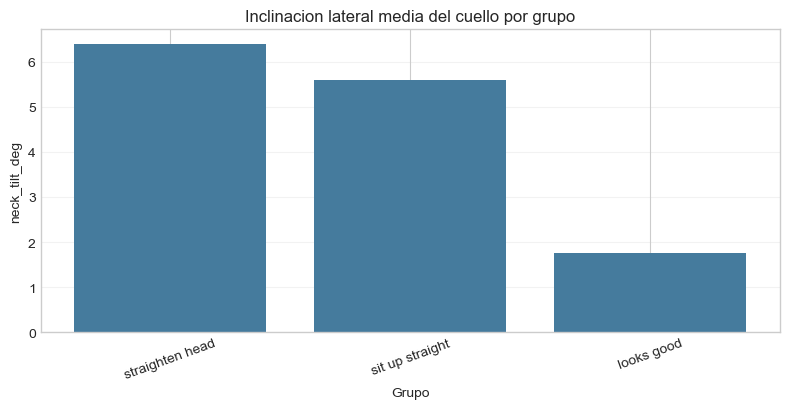

In [8]:
fig, ax = plot_status_distribution(demo_results_df)
plt.show()

fig, ax = plot_metric_by_group(
    demo_results_df,
    metric="shoulder_tilt_deg",
    title="Media de inclinacion de hombros por grupo",
)
plt.show()

fig, ax = plot_metric_by_group(
    demo_results_df,
    metric="head_lateral_offset_ratio",
    title="Desviacion lateral media de la cabeza por grupo",
)
plt.show()

fig, ax = plot_metric_by_group(
    demo_results_df,
    metric="neck_tilt_deg",
    title="Inclinacion lateral media del cuello por grupo",
)
plt.show()





## 5. Inspeccion visual de casos de ejemplo

Esta parte es importante para la siguiente iteracion:
no basta con obtener una etiqueta final; necesitamos ver si los landmarks y las reglas tienen sentido visualmente.
Por eso mostramos algunos ejemplos de la muestra con overlays sencillos de pose.





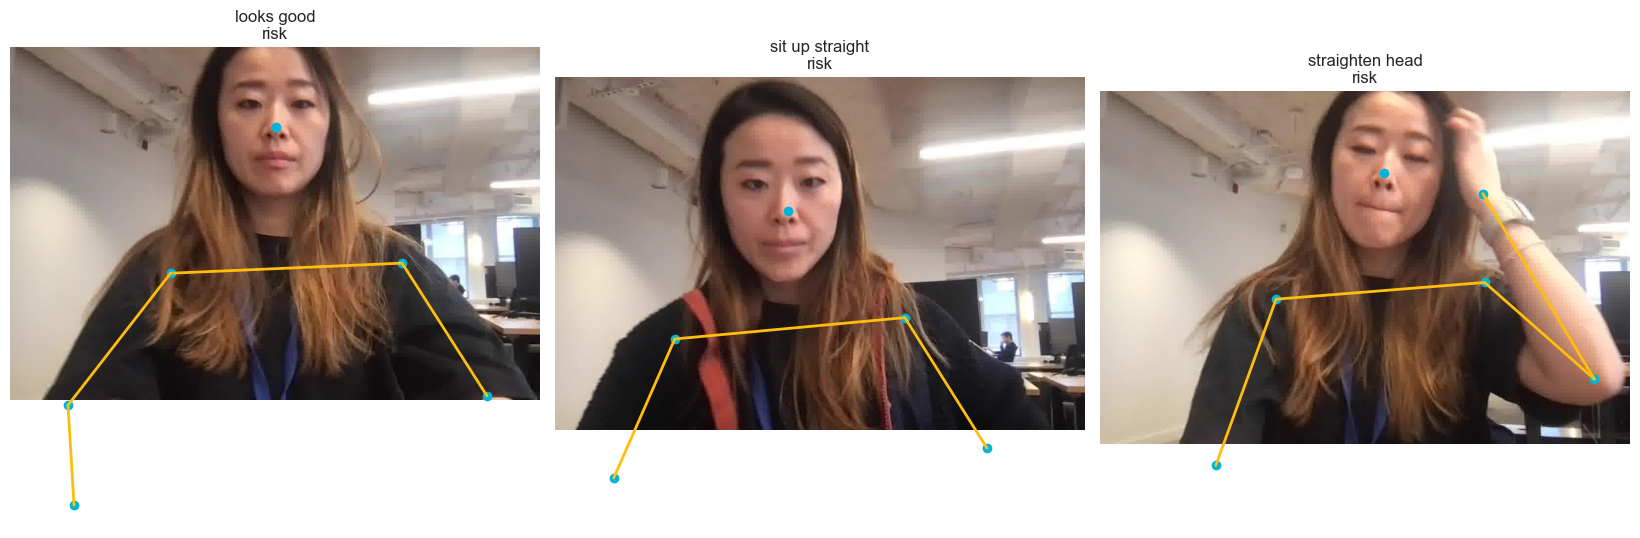

In [9]:
examples_df = (
    demo_results_df.sort_values(
        by=["overall_status", "group", "visible_landmarks_count"],
        ascending=[False, True, False],
    )
    .groupby("group", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, len(examples_df), figsize=(5.5 * len(examples_df), 5.5))
if len(examples_df) == 1:
    axes = [axes]

pose_lookup = pose_demo_df.set_index("image_path")

for ax, (_, example_row) in zip(axes, examples_df.iterrows(), strict=False):
    pose_row = pose_lookup.loc[example_row["image_path"]]
    draw_pose_overlay(example_row["image_path"], pose_row, ax=ax)
    ax.set_title(f"{example_row['group']}\n{example_row['overall_status']}")

plt.show()





In [10]:
display(
    examples_df[
        [
            "image_name",
            "group",
            "overall_status",
            "feedback",
        ]
    ]
)





,image_name,group,overall_status,feedback
0,extract1565_jpg.rf.8fabc715fae4681d745b97a6db1...,looks good,risk,Intenta mantener los hombros mas nivelados y r...
1,extract1049_jpg.rf.7a272f1bce23e4f0b2976d09af6...,sit up straight,risk,Intenta mantener los hombros mas nivelados y r...
2,extract1451_jpg.rf.63508a85f67903c920de0ae22b1...,straighten head,risk,Intenta mantener los hombros mas nivelados y r...


## 6. Lectura de esta iteracion

Lo importante de esta libreta no es solo que ejecute, sino lo que deja listo para la siguiente:
- ya tenemos un flujo modular `muestra -> landmarks -> variables -> reglas -> feedback`
- el notebook ya no contiene la logica pesada
- los umbrales y las reglas quedan en modulos que podremos ajustar sin reescribir la libreta

Siguiente paso recomendado:
- correr esta misma tuberia sobre mas imagenes del dataset base
- revisar ejemplos falsos positivos y falsos negativos para ajustar reglas
- decidir que reglas pasan a la siguiente fase estable del proyecto





In [11]:
phase_snapshot = pd.DataFrame(
    [
        {"item": "Modelo principal", "value": decision.primary_model},
        {"item": "Modelo de respaldo", "value": decision.backup_model},
        {"item": "Dataset de arranque", "value": TARGET_DATASET_KEY},
        {"item": "Total de imagenes de la demo", "value": len(sample_df)},
        {"item": "Threshold de visibilidad", "value": VISIBILITY_THRESHOLD},
        {"item": "Siguiente modulo esperado", "value": "mejora de variables y ajuste de reglas"},
    ]
)
display(phase_snapshot)




,item,value
0,Modelo principal,mediapipe_pose
1,Modelo de respaldo,movenet
2,Dataset de arranque,posture_correction_v4_folder_v1
3,Total de imagenes de la demo,12
4,Threshold de visibilidad,0.350
5,Siguiente modulo esperado,mejora de variables y ajuste de reglas


## 7. Escalado controlado del pipeline

Una demo de 12 imagenes sirve para comprobar que la tuberia funciona, pero sigue siendo pequena para leer patrones.
En esta ultima seccion ampliamos la muestra de forma moderada para responder a una pregunta mas util:

- que distribucion de estados sale por grupo cuando analizamos un lote algo mayor

No buscamos precision final todavia. Solo comprobar que la fase 2 ya es escalable sin cambiar de estructura.



In [12]:
EXPANDED_SAMPLE_PER_GROUP = 12

expanded_sample_df = select_balanced_sample(
    TARGET_DATASET_KEY,
    per_group=EXPANDED_SAMPLE_PER_GROUP,
    splits=("train", "valid", "test"),
    seed=11,
)
expanded_pose_df = run_mediapipe_pose_batch(expanded_sample_df, config=pose_config)
expanded_analysis_df = analyze_pose_dataframe(
    expanded_pose_df,
    visibility_threshold=VISIBILITY_THRESHOLD,
)

expanded_summary_df = (
    expanded_analysis_df.groupby(["group", "overall_status"], dropna=False)
    .size()
    .rename("image_count")
    .reset_index()
    .sort_values(["group", "overall_status"])
)

display(expanded_summary_df)
display(expanded_analysis_df["overall_status"].value_counts().rename("image_count"))



I0000 00:00:1776616239.206262   60683 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1776616239.208398   60694 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.25.10.1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1776616239.253880   60684 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776616239.270904   60684 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


,group,overall_status,image_count
0,looks good,adequate,3
1,looks good,improvable,7
2,looks good,risk,2
3,sit up straight,adequate,2
4,sit up straight,improvable,1
5,sit up straight,risk,9
6,straighten head,adequate,1
7,straighten head,improvable,1
8,straighten head,risk,10


overall_status
risk          21
improvable     9
adequate       6
Name: image_count, dtype: int64

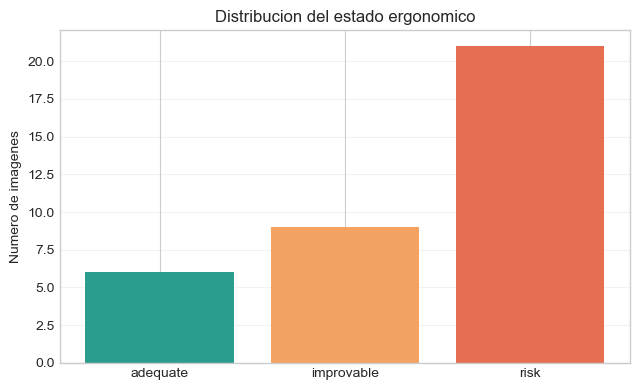

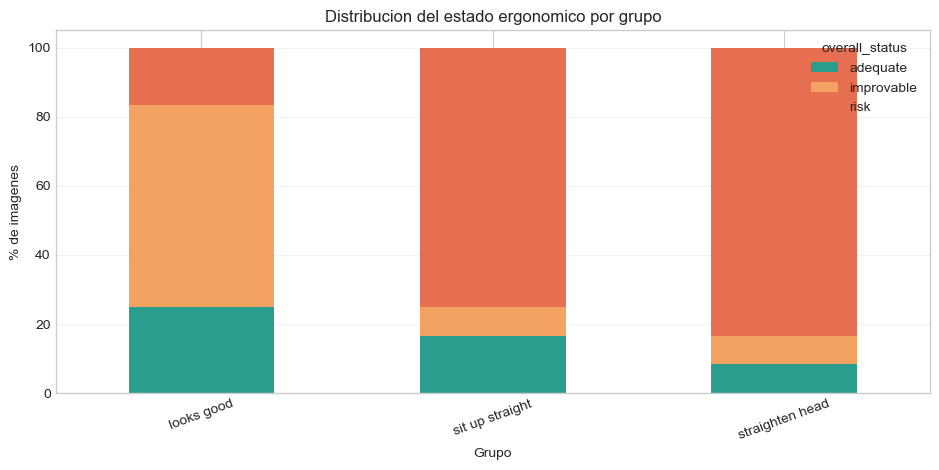

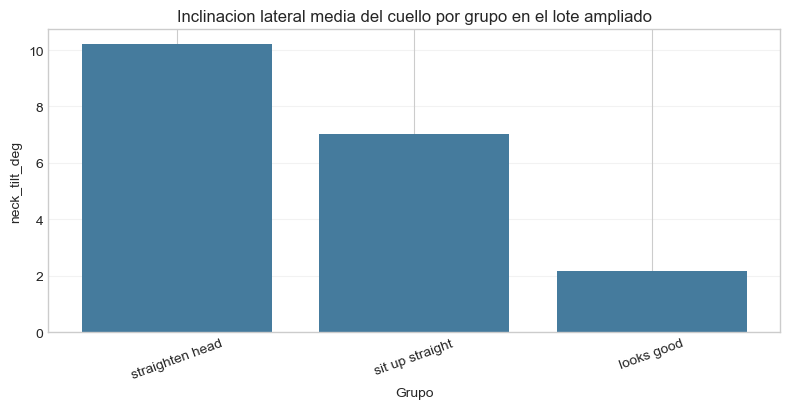

In [13]:
fig, ax = plot_status_distribution(expanded_analysis_df)
plt.show()

fig, ax = plot_status_by_group(expanded_analysis_df, normalize=True)
plt.show()

fig, ax = plot_metric_by_group(
    expanded_analysis_df,
    metric="neck_tilt_deg",
    title="Inclinacion lateral media del cuello por grupo en el lote ampliado",
)
plt.show()



In [14]:
expanded_phase_snapshot = pd.DataFrame(
    [
        {"item": "Imagenes del lote ampliado", "value": len(expanded_analysis_df)},
        {"item": "Adequate", "value": int((expanded_analysis_df["overall_status"] == "adequate").sum())},
        {"item": "Improvable", "value": int((expanded_analysis_df["overall_status"] == "improvable").sum())},
        {"item": "Risk", "value": int((expanded_analysis_df["overall_status"] == "risk").sum())},
    ]
)
display(expanded_phase_snapshot)


,item,value
0,Imagenes del lote ampliado,36
1,Adequate,6
2,Improvable,9
3,Risk,21
